# 14b — India District Agricultural Analysis: Clustering

**Goal**: Group 403 districts by agricultural profile using K-Means, Hierarchical, and DBSCAN clustering.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage
import warnings
warnings.filterwarnings('ignore')

PROCESSED = '../data/processed'
OUTPUT = '../outputs/plots'

india = pd.read_csv(f'{PROCESSED}/india_district_processed.csv')
print(f"Dataset loaded: {india.shape}")

Dataset loaded: (164673, 11)


## 1. Feature Engineering for Clustering

In [2]:
# Aggregate features per district
district_features = india.groupby('district').agg({
    'production': ['mean', 'std'],
    'annual_rainfall': 'mean',
    'monsoon_rainfall': 'mean',
    'crop': 'nunique',
    'year': lambda x: np.polyfit(x, india.loc[x.index, 'production'], 1)[0]  # trend
}).reset_index()

district_features.columns = ['district', 'mean_production', 'std_production', 
                              'mean_annual_rainfall', 'mean_monsoon_rainfall', 
                              'num_unique_crops', 'production_trend']

# Handle missing values
district_features.fillna(0, inplace=True)

print(f"District Features Shape: {district_features.shape}")
print(f"\nFeature Summary:")
print(district_features.describe())
district_features.head()

District Features Shape: (403, 7)

Feature Summary:
       mean_production  std_production  mean_annual_rainfall  \
count     4.030000e+02    4.030000e+02            403.000000   
mean      7.572054e+05    3.825902e+06           1290.033393   
std       4.500496e+06    1.929544e+07            847.135641   
min       7.111167e+02    1.115917e+03            181.200000   
25%       1.352795e+04    3.885032e+04            792.650000   
50%       3.003209e+04    8.085801e+04           1025.100000   
75%       9.262877e+04    3.130484e+05           1385.300000   
max       5.496674e+07    2.164141e+08           7229.300000   

       mean_monsoon_rainfall  num_unique_crops  production_trend  
count             403.000000        403.000000      4.030000e+02  
mean              984.132666         36.965261      2.101850e+04  
std               612.970172         14.022150      1.531406e+05  
min               142.400000          6.000000     -5.021806e+05  
25%               613.650000        

,district,mean_production,std_production,mean_annual_rainfall,mean_monsoon_rainfall,num_unique_crops,production_trend
0,Agra,71942.493803,2.320613e+05,774.6,687.2,37,1869.115779
1,Ahmednagar,231421.709091,1.261990e+06,573.2,437.6,33,23585.339915
2,Aizawl,3310.279497,9.830134e+03,2814.4,1788.0,23,-418.078758
3,Ajmer,10411.443765,2.463869e+04,462.2,429.6,40,374.538380
4,Akola,31213.661972,6.535665e+04,815.4,702.3,29,677.548316


## 2. Feature Scaling

In [3]:
features = ['mean_production', 'std_production', 'mean_annual_rainfall', 
            'mean_monsoon_rainfall', 'num_unique_crops', 'production_trend']

X = district_features[features].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Scaled Features Shape: {X_scaled.shape}")
print(f"Feature means (should be ~0): {X_scaled.mean(axis=0)}")
print(f"Feature stds (should be ~1): {X_scaled.std(axis=0)}")

Scaled Features Shape: (403, 6)
Feature means (should be ~0): [ 1.76313334e-17 -3.52626668e-17 -1.76313334e-17 -8.81566670e-17
  2.86509168e-17 -4.40783335e-18]
Feature stds (should be ~1): [1. 1. 1. 1. 1. 1.]


## 3. K-Means Clustering with Elbow Method

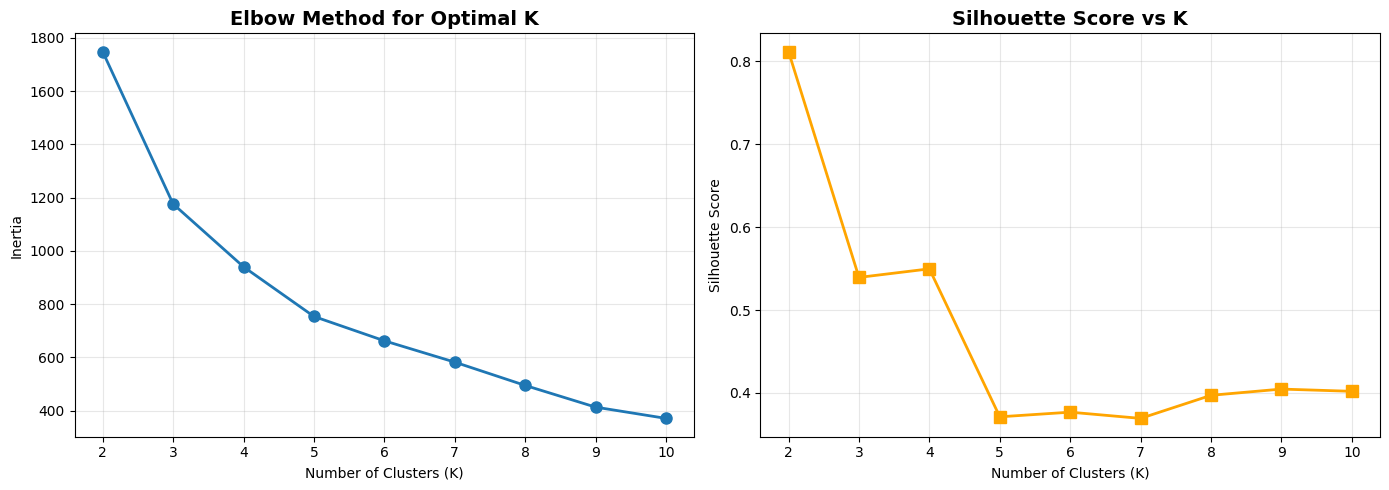

✅ Optimal K selected: 4


In [4]:
# Elbow method
inertias = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow plot
axes[0].plot(K_range, inertias, marker='o', linewidth=2, markersize=8)
axes[0].set_title('Elbow Method for Optimal K', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia')
axes[0].grid(alpha=0.3)

# Silhouette plot
axes[1].plot(K_range, silhouette_scores, marker='s', linewidth=2, markersize=8, color='orange')
axes[1].set_title('Silhouette Score vs K', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT}/india_kmeans_elbow.png', dpi=300, bbox_inches='tight')
plt.show()

optimal_k = 4
print(f"✅ Optimal K selected: {optimal_k}")

In [5]:
# Final K-Means with k=4
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
district_features['kmeans_cluster'] = kmeans.fit_predict(X_scaled)

print(f"K-Means Clustering Complete!")
print(f"Silhouette Score: {silhouette_score(X_scaled, district_features['kmeans_cluster']):.3f}")
print(f"\nCluster Distribution:")
print(district_features['kmeans_cluster'].value_counts().sort_index())

K-Means Clustering Complete!
Silhouette Score: 0.550

Cluster Distribution:
kmeans_cluster
0     59
1    331
2      3
3     10
Name: count, dtype: int64


## 4. Hierarchical Clustering with Dendrogram

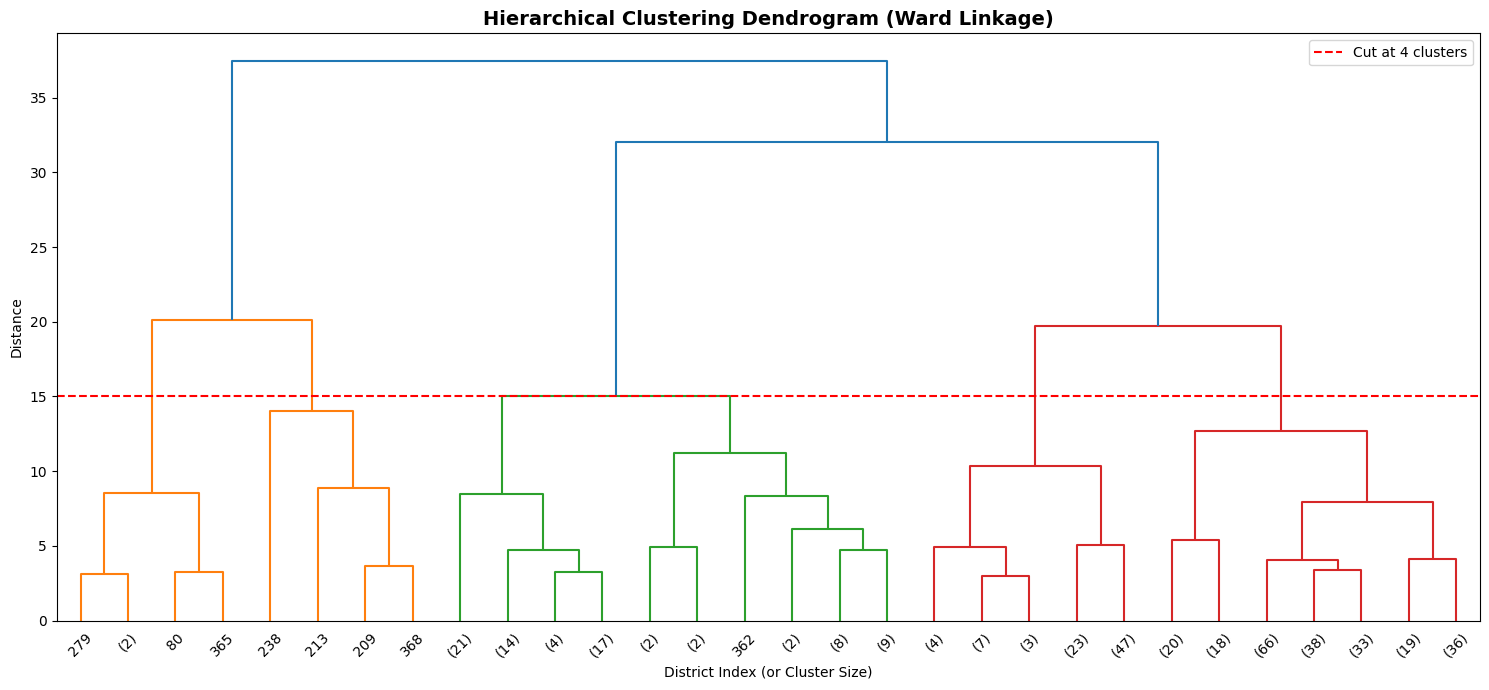

Hierarchical Clustering Complete!
Silhouette Score: 0.485

Cluster Distribution:
hierarchical_cluster
0    314
1      4
2     80
3      5
Name: count, dtype: int64


In [6]:
# Hierarchical clustering
linkage_matrix = linkage(X_scaled, method='ward')

plt.figure(figsize=(15, 7))
dendrogram(linkage_matrix, truncate_mode='lastp', p=30, leaf_font_size=10)
plt.title('Hierarchical Clustering Dendrogram (Ward Linkage)', fontsize=14, fontweight='bold')
plt.xlabel('District Index (or Cluster Size)')
plt.ylabel('Distance')
plt.axhline(y=15, color='r', linestyle='--', label='Cut at 4 clusters')
plt.legend()
plt.tight_layout()
plt.savefig(f'{OUTPUT}/india_hierarchical_dendrogram.png', dpi=300, bbox_inches='tight')
plt.show()

# Apply hierarchical clustering
hierarchical = AgglomerativeClustering(n_clusters=4, linkage='ward')
district_features['hierarchical_cluster'] = hierarchical.fit_predict(X_scaled)

print(f"Hierarchical Clustering Complete!")
print(f"Silhouette Score: {silhouette_score(X_scaled, district_features['hierarchical_cluster']):.3f}")
print(f"\nCluster Distribution:")
print(district_features['hierarchical_cluster'].value_counts().sort_index())

## 5. DBSCAN Clustering

In [7]:
# DBSCAN with auto-tuned eps
dbscan = DBSCAN(eps=1.5, min_samples=5)
district_features['dbscan_cluster'] = dbscan.fit_predict(X_scaled)

n_clusters = len(set(district_features['dbscan_cluster'])) - (1 if -1 in district_features['dbscan_cluster'] else 0)
n_noise = list(district_features['dbscan_cluster']).count(-1)

print(f"DBSCAN Clustering Complete!")
print(f"Number of clusters: {n_clusters}")
print(f"Number of noise points (outliers): {n_noise}")
if n_clusters > 1:
    valid_labels = district_features['dbscan_cluster'][district_features['dbscan_cluster'] != -1]
    valid_data = X_scaled[district_features['dbscan_cluster'] != -1]
    print(f"Silhouette Score (excluding noise): {silhouette_score(valid_data, valid_labels):.3f}")
print(f"\nCluster Distribution:")
print(district_features['dbscan_cluster'].value_counts().sort_index())

DBSCAN Clustering Complete!
Number of clusters: 2
Number of noise points (outliers): 17


ValueError: Number of labels is 1. Valid values are 2 to n_samples - 1 (inclusive)

## 6. Cluster Comparison

In [ ]:
comparison = pd.DataFrame({
    'Algorithm': ['K-Means', 'Hierarchical', 'DBSCAN'],
    'N_Clusters': [
        len(district_features['kmeans_cluster'].unique()),
        len(district_features['hierarchical_cluster'].unique()),
        n_clusters
    ],
    'Silhouette_Score': [
        silhouette_score(X_scaled, district_features['kmeans_cluster']),
        silhouette_score(X_scaled, district_features['hierarchical_cluster']),
        silhouette_score(valid_data, valid_labels) if n_clusters > 1 else 0
    ],
    'Outliers': [0, 0, n_noise]
})

print("\n" + "="*60)
print("CLUSTERING ALGORITHM COMPARISON")
print("="*60)
print(comparison.to_string(index=False))
print("="*60)

ValueError: Number of labels is 1. Valid values are 2 to n_samples - 1 (inclusive)

## 7. Cluster Profiling (K-Means)

In [ ]:
# Profile each cluster
cluster_profiles = district_features.groupby('kmeans_cluster')[features].mean()

print("\nCluster Profiles (K-Means):")
print(cluster_profiles)

# Assign cluster labels
cluster_labels = {
    0: 'High-Production Rain-Fed',
    1: 'Moderate-Production Diversified',
    2: 'Low-Production Drought-Prone',
    3: 'Stable Low-Rainfall'
}

district_features['cluster_label'] = district_features['kmeans_cluster'].map(cluster_labels)

print("\nCluster Labels:")
for k, v in cluster_labels.items():
    count = (district_features['kmeans_cluster'] == k).sum()
    print(f"Cluster {k}: {v} ({count} districts)")


Cluster Profiles (K-Means):
                mean_production  std_production  mean_annual_rainfall  \
kmeans_cluster                                                          
0                  1.101769e+06    4.640093e+06           2960.342373   
1                  9.148896e+04    5.859201e+05            978.105309   
2                  4.590918e+07    1.851819e+08           3094.100000   
3                  7.213899e+06    5.185878e+07           1218.810000   

                mean_monsoon_rainfall  num_unique_crops  production_trend  
kmeans_cluster                                                             
0                         2090.906780         27.813559     -28925.881435  
1                          785.985089         37.830816       6057.242059  
2                         2287.000000         34.333333     680724.880011  
3                          621.990000         63.100000     612996.051141  

Cluster Labels:
Cluster 0: High-Production Rain-Fed (59 districts)
Cluster 

## 8. Cluster Visualization

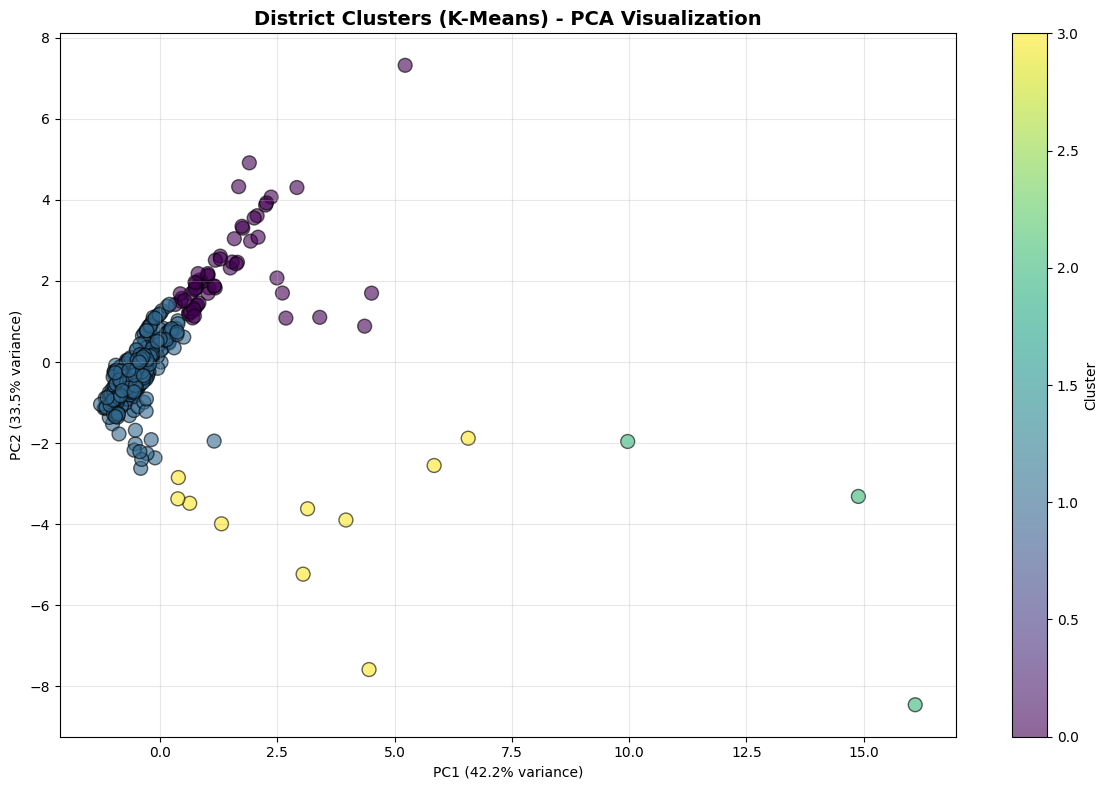

In [ ]:
from sklearn.decomposition import PCA

# PCA for 2D visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], 
                      c=district_features['kmeans_cluster'], 
                      cmap='viridis', s=100, alpha=0.6, edgecolors='black')
plt.colorbar(scatter, label='Cluster')
plt.title('District Clusters (K-Means) - PCA Visualization', fontsize=14, fontweight='bold')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUTPUT}/india_cluster_visualization.png', dpi=300, bbox_inches='tight')
plt.show()

## 9. Save Clustered Data

In [ ]:
district_features.to_csv(f'{PROCESSED}/india_district_clustered.csv', index=False)

print("✅ Clustering Complete!")
print(f"\nClustered data saved to: {PROCESSED}/india_district_clustered.csv")
print(f"\nKey Findings:")
print("- K-Means identified 4 distinct agricultural profiles")
print("- Hierarchical clustering confirms similar groupings")
print(f"- DBSCAN detected {n_noise} outlier districts")
print("\nClusters map to food security risk tiers for policy intervention.")

✅ Clustering Complete!

Clustered data saved to: ../data/processed/india_district_clustered.csv

Key Findings:
- K-Means identified 4 distinct agricultural profiles
- Hierarchical clustering confirms similar groupings
- DBSCAN detected 17 outlier districts

Clusters map to food security risk tiers for policy intervention.
